Will be implementing a few classes her

First one will be LQR solver with Riccati:
    Inputs for constructor:
        xhist, mu_distr, restrictions (using barrier)



In [1]:
import numpy as np
from autograd import grad, jacobian, hessian

In [51]:
class iLQR:
    def __init__(self, R, A, B, mu_distr, h, states_num, control_num, Tfinal, x0, v0):
        print("Init")
        self.R = R
        self.A = A
        self.B = B
        self.mu_distr = mu_distr
        self.h = h 
        self.states_num = states_num
        self.control_num = control_num
        self.N = int(Tfinal / h) + 1
        self.Q = np.zeros((states_num, states_num, self.N))
        
        # Constrains
        self.Eq = np.zeros((states_num, self.N))
        self.Ineq = np.zeros((states_num, self.N))
        self.EqMat = np.zeros((states_num , states_num, self.N))
        self.IneqMat = np.zeros((states_num , states_num, self.N))
        self.lm = np.zeros(( states_num, self.N))
        self.m = np.zeros(( states_num, self.N))
        
        self.p = 1
        # Violation increase
        self.phi = 1.1
        
        # Setting initial coordinates
        self.xhist = np.ones((states_num, self.N))
        self.xhist[0, :] = x0
        self.xhist[1, :] = v0
        
        self.uhist = np.zeros((control_num, self.N))
        print("Uhist initialized as ", self.uhist.shape)
        
        # Forward pass variables
        self.P = np.zeros((states_num, states_num, self.N))
        self.pp = np.zeros((states_num, self.N))
        self.K = np.zeros((control_num, states_num, self.N - 1))
        self.d = np.zeros((control_num, self.N - 1))
        
        # Utility
        self.Last_error = 0
        self.Equality_error = 0
        self.Inequality_error = 0
        
        # Handmade changes
        
        # Setting constraint x equal to 2
        self.EqMat[0,0 , :] = 1
        self.EqMat[1,1 , :] = 1
        self.Eq[0,:] = 8
        self.Eq[1,:] = 3
        
    def backward_pass(self):
        print("Backward pass in the area")
        
        Error = 0
        
        # Cleaning
        self.P *= 0
        self.K *= 0
        self.pp *= 0
        
        # Linearize dynamics
        # In my case, linear so no need
        
        x = self.xhist[:, self.N - 1]
        u = np.zeros((self.control_num))
        
        # Computing last state Q
        k = self.N - 1
        L_fixed = lambda x_arg: self.L(x_arg, u, self.lm[:, k], self.p, self.EqMat[:, :, k], self.Eq[:, k])
        H = hessian(L_fixed)(x)
        G = grad(L_fixed)(x)
        self.Q[:, :, k] = H
        self.P[:, :, k] = self.Q[:, :, k]
        self.pp[:, k] =  G
        
        # KP calculations
        for i in range(self.N - 2, -1, -1):
            # Computing Q for previous
            x = self.xhist[:, i]
            u = self.uhist[:, i]
            L_fixed = lambda x_arg: self.L(x_arg, u, self.lm[:, i], self.p, self.EqMat[:, :, i], self.Eq[:, i])
            H = hessian(L_fixed)(x)
            self.Q[:, :, i] = H

            q = self.Q[:, :, i] @ self.xhist[:, i]
            r = self.R @ self.uhist[:, i]
            
            # Derivatives of Q (S) respect to x and u
            L_fixed_x = lambda x_arg: self.L(x_arg, u, self.lm[:, i], self.p, self.EqMat[:, :, i], self.Eq[:, i])
            L_fixed_u = lambda u_arg: self.L(x, u_arg, self.lm[:, i], self.p, self.EqMat[:, :, i], self.Eq[:, i])

            lx = grad(L_fixed_x)(x)
            lu = grad(L_fixed_u)(u)

            gx = lx + self.A.T @ self.pp[:, i + 1]
            gu = lu + self.B.T @ self.pp[:, i + 1]
            
            #iLQR Gauss Newton (ignoring 2 order terms)
            Gxx = self.Q[:, :, i] + self.A.T @ self.P[:, :, i + 1] @ self.A
            Guu = ( self.R + self.B.T @ self.P[:, :, i + 1] @ self.B )
            Gxu = self.A.T @ self.P[:, :, i + 1] @ self.B
            Gux = self.B.T @ self.P[:, :, i + 1] @ self.A
            
            # Regularizing Guu cuz we are taking its inverse
            beta = 1e-6
            Guu = Guu + beta * np.eye(self.control_num)
            
            # Computing important thing
            self.d[:, i] = np.linalg.solve(Guu, gu)
            self.K[:, :, i] = np.linalg.solve(Guu, Gux) 
            
            self.pp[:, i] = gx - self.K[:, :, i].T @ gu + self.K[:, :, i].T @ Guu @ self.d[:,i] - Gxu @ self.d[:,i]
            self.P[:, :, i] = Gxx + self.K[:, :, i].T @ Guu @ self.K[:, :, i] - Gxu @ self.K[:, :, i] - self.K[:, :, i].T @ Gux
        
            Error += gu.T * self.d[:, i]
        
        return Error
    def compute_Q(self):
        
        # Depreciated
        
        print("Compute Q")
        # Take Hessian of L with respect to x
        for k in range(self.N):
            x = self.xhist[:, k]
            u = self.uhist[:, k] if k < self.N-1 else np.zeros((self.control_num))
            L_fixed = lambda x_arg: self.L(x_arg, u, self.lm[:, k], self.p, self.EqMat[:, :, k], self.Eq[:, k])
            H = hessian(L_fixed)(x)
            self.Q[:, :, k] = H
    
    def L(self, x, u, lm, p, EqMat, Eq):
        # Cost to be minimized
        # Will replace i with full matrix mult later
        basic_err = x.T @ x + u.T @ u
        
        #Equality
        
        try:
            EqDiff = (EqMat @ x - Eq.flatten())
            EqErr = lm.T @ EqDiff + p/2 * EqDiff.T @ EqDiff
            self.Equality_error = EqErr
        except:
            print("Equality terms mismatch")
        
        #Inequality
        
        try:
            self.Last_error = basic_err + EqErr 
            return basic_err + EqErr
        except:
            print("Error shaped didn't match")
            print(basic_err.shape, barrier.shape, u.T.shape, self.R.shape, u.shape)
    
    def report(self, xhist_=None, uhist_=None, silent=False):
        if xhist_ is None: xhist_ = self.xhist
        if uhist_ is None: uhist_ = self.uhist

        total_basic = 0.0
        total_eq = 0.0
        for k in range(self.N):
            x = xhist_[:, k]
            u = uhist_[:, k] if k < self.N - 1 else np.zeros(self.control_num)
            lm_k = self.lm[:, k]

              # ---- Basic quadratic cost ----
            basic_err = x.T @ x + u.T @ u
            total_basic += basic_err

            # ---- Equality constraint ----
            EqDiff = self.EqMat[:,:, k] @ x - self.Eq[:, k].flatten()
            EqErr = lm_k.T @ EqDiff + self.p/2 * (EqDiff.T @ EqDiff)
            total_eq += EqErr

        total_cost = total_basic + total_eq

        if not silent:
            print("========== REPORT ==========")
            print("Total cost:      ", total_cost)
            print("State-control:   ", total_basic)
            print("Equality cost:   ", total_eq)
            print("Penalty p:       ", self.p)
            print("============================")
        return total_cost

    def dynamics(self, x, u):
        return self.A @ x + self.B @ u
    
    def reset_xhist(self):
        self.xhist = np.zeros_like(self.xhist)
    
    def rollout(self):
        Error = self.backward_pass()
        
        xnew = np.zeros_like(self.xhist)
        xnew[:, 0] = self.xhist[:, 0]
        u_nominal = np.zeros_like(self.uhist)
        alpha_line = 1
        # Line search
        En = self.report(silent = False)
        while alpha_line > 1e-3:
            
            for k in range(0, self.N - 1):
                # use dx and not full state because we want to keep near xhist, or linearization stops beign correct
                dx = xnew[:, k] - self.xhist[:, k]
                u_nominal[:, k] = self.uhist[:, k] - alpha_line * self.d[:, k] - np.dot(self.K[:, :, k], dx) 
                xnew[:, k + 1] = self.dynamics(xnew[:, k], u_nominal[:, k]) 
            NE = self.report(xnew, u_nominal, True)
            if NE < En:
                # I will put Armijo condition later
                break
            alpha_line *= 0.5
            
        # Copy for further iterations
        self.xhist = xnew    
        self.uhist = u_nominal
        
        return self.xhist, self.uhist, NE
    
    def rollout_i(self, n, eps = 1e-3):
        self.p = 1
        for _ in range(n):
            self.report()
            for _ in range(5):
                # Converging on lagrangiangs
                _, _, new_iteration_error = self.rollout();
            # Augmenting lagrangian
            for i in range(self.N):
                # Equality constraint
                self.lm[:, i] = self.lm[:, i] + self.p * (self.EqMat[:, :, i] @ self.xhist[:, i] - self.Eq[:, i].flatten())
            # 
            self.p = self.p * self.phi
        return self.xhist, self.uhist



In [52]:
import matplotlib.pyplot as plt

# Test
h = 0.01
A = np.array( [[1, 0, h , 0], [0, 1, 0, h], [0, 0, 1, 0], [0, 0, 0, 1]] )
print(A)
B = np.array( [[0.5 * h * h, 0] , [0, 0.5 * h * h ], [h , 0], [0 , h] ] )
print(B)
n = 4 # number of states
m = 2 # number of controls
R = np.identity(2)
Tfinal = 5.0 # final time
mu_distr = 0

iLQR_inst = iLQR(R, A, B, mu_distr, h, n, m, Tfinal, -10, 10)



[[1.   0.   0.01 0.  ]
 [0.   1.   0.   0.01]
 [0.   0.   1.   0.  ]
 [0.   0.   0.   1.  ]]
[[5.e-05 0.e+00]
 [0.e+00 5.e-05]
 [1.e-02 0.e+00]
 [0.e+00 1.e-02]]
Init
Uhist initialized as  (2, 501)


In [53]:
# Rollout
xhist, uhist = iLQR_inst.rollout_i(10)



========== REPORT ==========
Total cost:       194638.5
State-control:    101202.0
Equality cost:    93436.5
Penalty p:        1
Backward pass in the area
========== REPORT ==========
Total cost:       194638.5
State-control:    101202.0
Equality cost:    93436.5
Penalty p:        1
Backward pass in the area
========== REPORT ==========
Total cost:       70300.6801159413
State-control:    48129.28625967072
Equality cost:    22171.393856270588
Penalty p:        1
Backward pass in the area
========== REPORT ==========
Total cost:       67345.76325065817
State-control:    38761.659840256456
Equality cost:    28584.103410401713
Penalty p:        1
Backward pass in the area
========== REPORT ==========
Total cost:       67049.44406583458
State-control:    40206.230990621996
Equality cost:    26843.213075212592
Penalty p:        1
Backward pass in the area
========== REPORT ==========
Total cost:       66937.17046769641
State-control:    39169.02296312543
Equality cost:    27768.14750457099


========== REPORT ==========
Total cost:       343232.5992421787
State-control:    109243.12088616955
Equality cost:    233989.4783560092
Penalty p:        1.771561000000001
Backward pass in the area
========== REPORT ==========
Total cost:       343149.40291888954
State-control:    103464.67880917885
Equality cost:    239684.7241097107
Penalty p:        1.771561000000001
Backward pass in the area
========== REPORT ==========
Total cost:       343122.6711858618
State-control:    106648.78308051993
Equality cost:    236473.8881053419
Penalty p:        1.771561000000001
Backward pass in the area
========== REPORT ==========
Total cost:       343110.99326577917
State-control:    104555.49673130215
Equality cost:    238555.49653447702
Penalty p:        1.771561000000001
========== REPORT ==========
Total cost:       390093.3182603652
State-control:    106026.06089457423
Equality cost:    284067.257365791
Penalty p:        1.9487171000000014
Backward pass in the area
========== REPORT =====

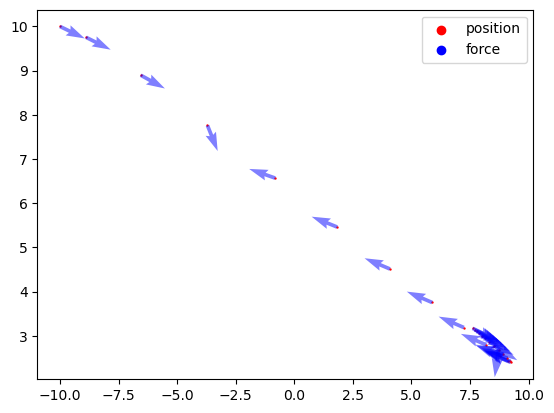

In [54]:
fig, ax = plt.subplots(1)
for k in range(0, xhist.shape[1] - 1, 20):
    ax.scatter(xhist[0,k], xhist[1,k], color="red", s=0.5)
    ax.quiver(xhist[0,k], xhist[1,k], uhist[0,k], uhist[1,k], color="blue", alpha=0.5)

ax.scatter([], [], color="red", label="position")
ax.scatter([], [], color="blue", label="force")
ax.legend()
